In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

feature_names = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

columns = ["id", "diagnosis"] + feature_names

In [3]:
df = pd.read_csv(
    "wdbc.data",
    header=None,
    names=columns
)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (569, 32)
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  

In [4]:
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["diagnosis"].value_counts())


Missing Values:
0

Class Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64


In [5]:
df["diagnosis"] = df["diagnosis"].map({
    "B": 0,
    "M": 1
})

print(df["diagnosis"].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [6]:
X = df[feature_names]

y = df["diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


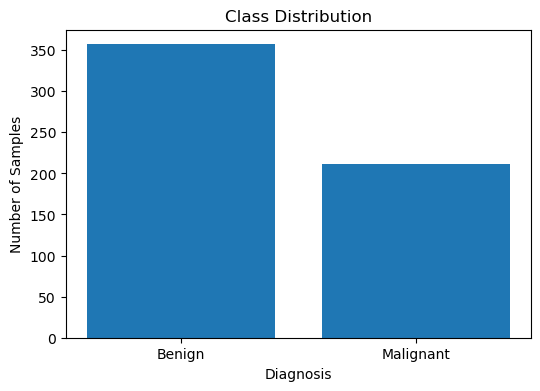

In [7]:
class_counts = df["diagnosis"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ["Benign", "Malignant"],
    [
        class_counts[0],
        class_counts[1]
    ]
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.show()

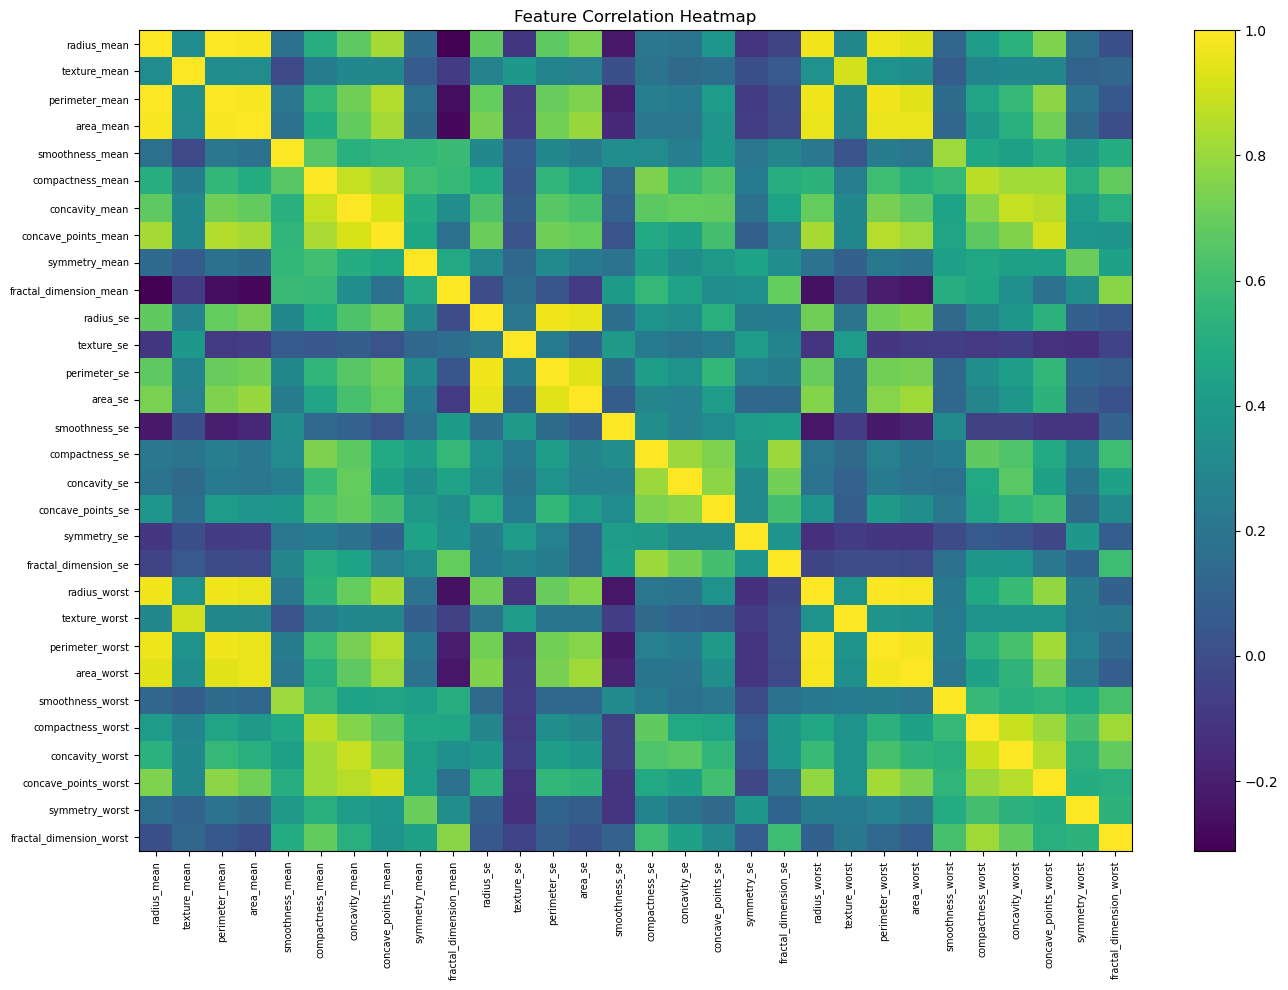

In [8]:
correlation_matrix = X.corr()

plt.figure(figsize=(14, 10))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(30),
    feature_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(30),
    feature_names,
    fontsize=7
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()

plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 455
Testing samples: 114


In [13]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [15]:
dt_grid = GridSearchCV(
    dt,
    dt_param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1,
    return_train_score=True
)

dt_grid.fit(X_train, y_train)
print()

In [16]:
print("Best Decision Tree Parameters:")
print(dt_grid.best_params_)

print("\nBest CV Accuracy:")
print(round(dt_grid.best_score_, 4))

Best Decision Tree Parameters:
{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best CV Accuracy:
0.9407


In [17]:
dt_results = pd.DataFrame(
    dt_grid.cv_results_
)

dt_table = dt_results[
    [
        "param_criterion",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

dt_table.columns = [
    "Criterion",
    "Max Depth",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score (%)"
]

dt_table["Avg CV Accuracy (%)"] *= 100
dt_table["Avg CV F1 Score (%)"] *= 100

dt_table = dt_table.round(2)

dt_table = dt_table.sort_values(
    "Avg CV Accuracy (%)",
    ascending=False
)

print(dt_table)

   Criterion Max Depth  Avg CV Accuracy (%)  Avg CV F1 Score (%)
93   entropy         4                94.07                91.63
94   entropy         4                94.07                91.63
95   entropy         4                93.85                91.42
90   entropy         4                93.85                91.45
91   entropy         4                93.63                91.08
..       ...       ...                  ...                  ...
56      gini        10                91.21                87.99
65      gini      None                91.21                87.99
29      gini         5                90.99                87.59
38      gini         6                90.99                87.59
27      gini         5                90.77                87.17

[144 rows x 4 columns]


In [18]:
best_dt = dt_grid.best_estimator_

best_dt.fit(
    X_train,
    y_train
)

dt_pred = best_dt.predict(X_test)

dt_prob = best_dt.predict_proba(
    X_test
)[:, 1]

In [21]:
rf = RandomForestClassifier(
    random_state=42
)

rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1": "f1"
    },
    refit="accuracy",
    n_jobs=-1,
    return_train_score=True
)

rf_grid.fit(
    X_train,
    y_train
)
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest CV Accuracy:")
print(round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}

Best CV Accuracy:
0.9714


In [22]:
rf_results = pd.DataFrame(
    rf_grid.cv_results_
)

rf_table = rf_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

rf_table.columns = [
    "n estimators",
    "Max Depth",
    "Max Features",
    "Avg CV Accuracy (%)",
    "Avg CV F1 Score (%)"
]

rf_table["Avg CV Accuracy (%)"] *= 100
rf_table["Avg CV F1 Score (%)"] *= 100

rf_table = rf_table.round(2)

rf_table = rf_table.sort_values(
    "Avg CV Accuracy (%)",
    ascending=False
)

print(rf_table)

    n estimators Max Depth Max Features  Avg CV Accuracy (%)  \
32           200         5         sqrt                97.14   
36            50        10         sqrt                97.14   
38           200        10         sqrt                97.14   
44           200        15         sqrt                97.14   
26           200      None         sqrt                97.14   
27            50      None         log2                96.92   
31           100         5         sqrt                96.92   
24            50      None         sqrt                96.92   
42            50        15         sqrt                96.92   
45            50        15         log2                96.92   
40           100        10         log2                96.92   
39            50        10         log2                96.92   
7            100         5         sqrt                96.70   
34           100         5         log2                96.70   
28           100      None         log2 

In [23]:
best_rf = rf_grid.best_estimator_

best_rf.fit(
    X_train,
    y_train
)

rf_pred = best_rf.predict(X_test)

rf_prob = best_rf.predict_proba(
    X_test
)[:, 1]

In [24]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Decision Tree")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))

print("\nRandom Forest")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Decision Tree
Accuracy : 0.9298
Precision: 1.0
Recall   : 0.8095
F1 Score : 0.8947

Random Forest
Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963


In [25]:
dt_cm = confusion_matrix(y_test, dt_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

Decision Tree Confusion Matrix:
[[72  0]
 [ 8 34]]

Random Forest Confusion Matrix:
[[72  0]
 [ 3 39]]


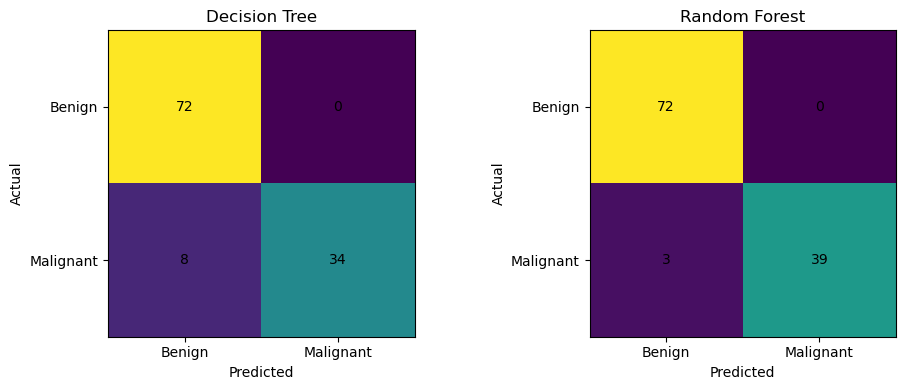

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(dt_cm)

axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])

axes[0].set_xticklabels(["Benign", "Malignant"])
axes[0].set_yticklabels(["Benign", "Malignant"])

for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            dt_cm[i, j],
            ha="center",
            va="center"
        )


axes[1].imshow(rf_cm)

axes[1].set_title("Random Forest")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

axes[1].set_xticklabels(["Benign", "Malignant"])
axes[1].set_yticklabels(["Benign", "Malignant"])

for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            rf_cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [28]:
dt_fpr, dt_tpr, _ = roc_curve(
    y_test,
    dt_prob
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_prob
)

dt_auc = roc_auc_score(
    y_test,
    dt_prob
)

rf_auc = roc_auc_score(
    y_test,
    rf_prob
)

print("Decision Tree AUC :", round(dt_auc, 4))
print("Random Forest AUC :", round(rf_auc, 4))

Decision Tree AUC : 0.9563
Random Forest AUC : 0.994


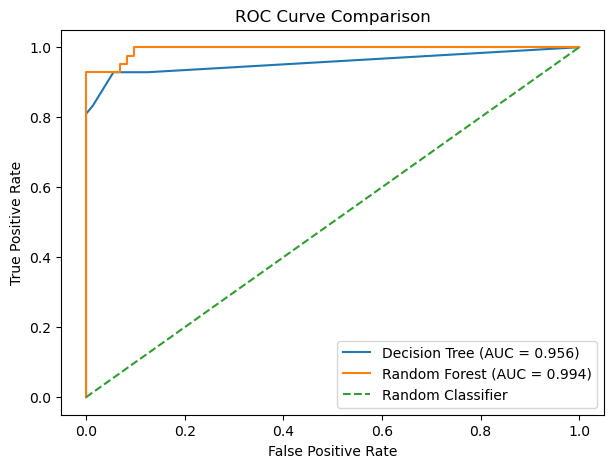

In [29]:
plt.figure(figsize=(7, 5))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [30]:
dt_cv_scores = cross_val_score(
    best_dt,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

rf_cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
)

In [31]:
print("Decision Tree CV Scores:")
print(dt_cv_scores)

print("\nRandom Forest CV Scores:")
print(rf_cv_scores)

cv_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Fold 1": [
        dt_cv_scores[0],
        rf_cv_scores[0]
    ],
    "Fold 2": [
        dt_cv_scores[1],
        rf_cv_scores[1]
    ],
    "Fold 3": [
        dt_cv_scores[2],
        rf_cv_scores[2]
    ],
    "Fold 4": [
        dt_cv_scores[3],
        rf_cv_scores[3]
    ],
    "Fold 5": [
        dt_cv_scores[4],
        rf_cv_scores[4]
    ],
    "Average": [
        dt_cv_scores.mean(),
        rf_cv_scores.mean()
    ]
})

cv_comparison.iloc[:, 1:] = (
    cv_comparison.iloc[:, 1:] * 100
).round(2)

print(cv_comparison)

Decision Tree CV Scores:
[0.93406593 0.95604396 0.9010989  0.95604396 0.95604396]

Random Forest CV Scores:
[0.96703297 0.97802198 0.95604396 0.96703297 0.98901099]
           Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Average
0  Decision Tree   93.41    95.6   90.11    95.6    95.6    94.07
1  Random Forest   96.70    97.8   95.60    96.7    98.9    97.14


In [32]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        dt_precision,
        rf_precision
    ],
    "Recall": [
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        dt_f1,
        rf_f1
    ],
    "AUC": [
        dt_auc,
        rf_auc
    ]
})

comparison.iloc[:, 1:] = (
    comparison.iloc[:, 1:] * 100
).round(2)

print(comparison)

           Model  Accuracy  Precision  Recall  F1 Score    AUC
0  Decision Tree     92.98      100.0   80.95     89.47  95.63
1  Random Forest     97.37      100.0   92.86     96.30  99.40


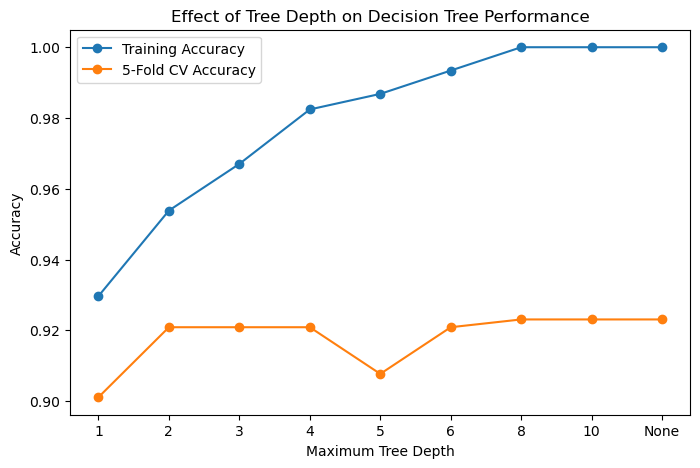

In [34]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

train_scores = []
cv_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    cv_scores.append(
        cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        ).mean()
    )

plt.figure(figsize=(8, 5))

x_labels = [
    "1", "2", "3", "4", "5",
    "6", "8", "10", "None"
]

plt.plot(
    x_labels,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    x_labels,
    cv_scores,
    marker="o",
    label="5-Fold CV Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Decision Tree Performance")

plt.legend()

plt.show()